In [7]:
import numpy as np
from copy import copy
import bisect

def get_support(x):
   # returns the support of input vector x
   return list(np.where(x>0)[0])

def get_neg_support(x):
   # returns the support of input vector x
   return list(np.where(x<0)[0])

def activeset(y,W,x):
   # Initialize the support and restricted LS solutions
   supp = get_support(x)
   res = y - W@x
   print(f"Residual: {np.linalg.norm(y - W@x)}, support {supp}")

   # main AS loop, stop when the support does not change
   iter = 0
   old_supp = [-1]  #anything different than initial support
   while supp != old_supp:
      old_supp = copy(supp)
      iter += 1
      print(f"Iteration {iter}")
      # 1. Support update: find the "most negative" Lagrange multiplier
      if len(supp) < len(x):  # if the support is full do not update the support (only happens at init)
         dual_params = W.T@res
         dual_params[supp] = -np.inf # zero out the entries corresponding to the current support
         idx = np.argmax(dual_params)
         bisect.insort(supp, idx)  # insert support index while keeping sorted
         
      # 2. Unconstrained Least Squares restricted to the support
      ls_sol = np.linalg.lstsq(W[:,supp], y, rcond=None)[0]
      # embed ls_sol into full space
      ls_sol_full = np.zeros_like(x)
      ls_sol_full[supp] = ls_sol
      neg_supp = get_neg_support(ls_sol_full)

      # 3. Support iterative refinement, to ensure ls_sol is nonnegative
      while len(neg_supp) > 0:
         # Move along the line from previous to candidate estimate, until the cone is crossed
         t = np.min(x[neg_supp]/(x[neg_supp]-ls_sol_full[neg_supp])) 
         # Update x to decrease the cost along the line (x, ls_sol-x), until the constraints are active
         x = x + t*(ls_sol_full - x)
         # Update the support (remove one element)
         supp = get_support(x)
         # Recompute LS solution on the new support and count negative entries
         ls_sol = np.linalg.lstsq(W[:,supp], y, rcond=None)[0]
         ls_sol_full = np.zeros_like(x)
         ls_sol_full[supp] = ls_sol
         neg_supp = get_neg_support(ls_sol_full)
         print(f"Residual: {np.linalg.norm(y - W@x)}, support {supp}, step {t}")
      
      # Update x with new nonnegative ls_sol 
      x = ls_sol_full
      res = y - W@x

      # printing error for following AS progress
      print(f"Residual: {np.linalg.norm(res)}, support {supp}")

   return x, supp



In [13]:
np.random.seed(2)
m=6
n=50
W = np.random.rand(m,n)
support = [0,2,4]
xtrue = np.zeros(n)
xtrue[support] = np.random.rand(3)
y = W@xtrue + 0.1*np.random.randn(m)
x0 = np.zeros(n)
#x0 = np.random.rand(n)
x_opt, est_support = activeset(y,W,x0)
print("Optimal x:", x_opt)
print(f"Optimality criterion on estimated support: {np.linalg.norm(W[:,est_support].T@(y-W@x_opt))}")
print(f"Optimality criterion on true support: {np.linalg.norm(W[:,support].T@(y-W@x_opt))}")

Residual: 0.7332827438506135, support []
Iteration 1
Residual: 0.34036387671449636, support [49]
Iteration 2
Residual: 0.23756836129567335, support [41, 49]
Iteration 3
Residual: 0.16861002184543528, support [7, 41, 49]
Iteration 4
Residual: 0.15317817929560062, support [3, 7, 41], step 0.13149418992974357
Residual: 0.13413207652719195, support [3, 7, 41]
Iteration 5
Residual: 0.10556301170510979, support [3, 4, 7, 41]
Iteration 6
Residual: 0.0519536934584759, support [3, 4, 41, 44], step 0.5419766926290845
Residual: 0.04449646221989813, support [4, 41, 44], step 0.484169692936829
Residual: 0.04207535623520433, support [4, 41, 44]
Iteration 7
Residual: 0.04207535623520433, support [4, 41, 44], step 0.0
Residual: 0.04207535623520433, support [4, 41, 44]
Optimal x: [0.         0.         0.         0.         0.00500251 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.  

In [3]:
import tensorly as tl
import numpy as np

def hals_nnls(
    UtM,
    UtU,
    V=None,
    n_iter_max=500,
    tol=1e-8,
    epsilon=0.0,
):
    rank, _ = tl.shape(UtM)
    if V is None:
        V = tl.solve(UtU, UtM)
        V = tl.clip(V, a_min=0, a_max=None)

    for iteration in range(n_iter_max):
        rec_error = 0
        for k in range(rank):
            if UtU[k, k]:
                num = UtM[k, :] - tl.dot(UtU[k, :], V) + UtU[k, k] * V[k, :]
                den = UtU[k, k]

                V[k,:] = tl.clip(num / den, a_min=epsilon)
                rec_error += tl.norm(V - V[k,:]) ** 2

        if iteration == 0:
            rec_error0 = rec_error
        if rec_error < tol * rec_error0:
            break

    return V

In [ ]:
np.random.seed(2)
m=10
r = 6
n=20
W = np.random.rand(m,r)
Htrue = np.random.randn(r,n)
Htrue[Htrue<0] = 0  # sparsify true H
Y = W@Htrue + 0.01*np.random.randn(m, n)
errs = []
def callback_err(H):
   errs.append(np.linalg.norm(Y - W@H)/np.linalg.norm(Y))
   return True
Hest = hals_nnls(W.T@Y, W.T@W, n_iter_max=100, tol=1e-6, callback=callback)
print(f"Relative Reconstruction error: {np.linalg.norm(Y - W@Hest)/np.linalg.norm(Y)}")
print(f"Mean square error on H: {np.linalg.norm(Htrue - Hest)/r/n}")

plt.figure()
plt.semilogy(errs)
plt.xlabel("Iteration")
plt.ylabel("Relative Reconstruction Error")
plt.title("HALS NNLS with Callback Error Monitoring")
plt.grid()
plt.show()

Relative Reconstruction error: 0.004666660655171395
Mean square error on H: 0.0009439678563046575


In [40]:
import tensorly as tl
import numpy as np
from tensorly.solvers import hals_nnls
from time import perf_counter

def BCD_hals(Y,Winit,Hinit,n_inner,n_outer):
    W = np.copy(Winit)
    H = np.copy(Hinit)
    #loss = [np.linalg.norm(Y - W@H.T,'fro')**2]
    #time = [0]
    start = perf_counter()
    loss = []
    time = []
    
    for it in range(n_outer):
        # Update H
        UtM = W.T @ Y
        UtU = W.T @ W
        H = hals_nnls(UtM, UtU, V=H.T, n_iter_max=n_inner, tol=0).T

        # Update W
        VtM = H.T @ Y.T
        VtV = H.T @ H
        W = hals_nnls(VtM, VtV, V=W.T, n_iter_max=n_inner, tol=0).T

        loss.append(np.linalg.norm(Y - W@H.T,'fro')**2)
        time.append(perf_counter() - start)
        #print(f"Iteration {it+1}, loss: {loss[-1]}, time: {time[-1]:.4f}s")
    return W, H, loss, time
    

# Generate toy synthetic nonnegative tensor data
np.random.seed(0)
shape = [2000, 50]
rank = 3
Wtrue, Htrue = [np.random.rand(s, rank) for s in shape]
Y = Wtrue @ Htrue.T
Winit = np.random.rand(shape[0], rank)
Hinit = np.random.rand(shape[1], rank)
results = {}

for n_inner in [1,2,3,5,10,20,100]:
    print(f"Running BCD-HALS with n_inner={n_inner}")
    West, Hest, loss, time_ = BCD_hals(Y, Winit=Winit, Hinit=Hinit, n_inner=n_inner, n_outer=800)
    results[n_inner] = (loss, time_)

Running BCD-HALS with n_inner=1
Running BCD-HALS with n_inner=2
Running BCD-HALS with n_inner=3
Running BCD-HALS with n_inner=5
Running BCD-HALS with n_inner=10
Running BCD-HALS with n_inner=20
Running BCD-HALS with n_inner=100


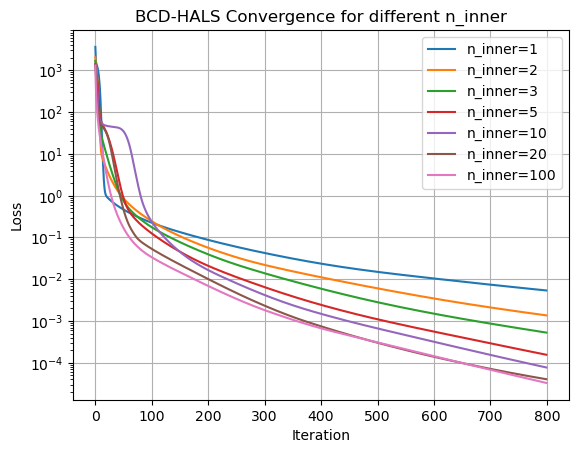

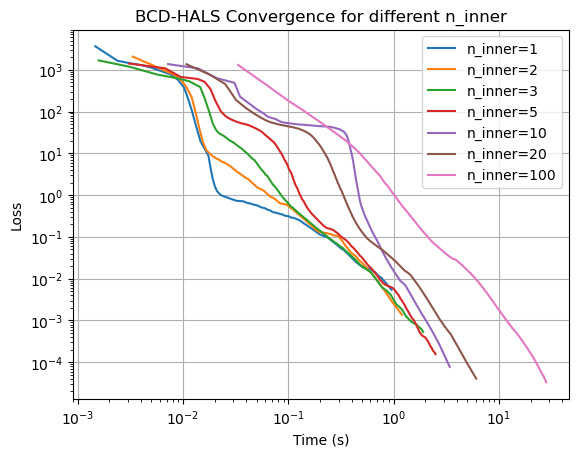

In [42]:
# Iteration plot
import matplotlib.pyplot as plt
plt.figure()
for n_inner, (loss, time_) in results.items():
    plt.semilogy(loss, label=f"n_inner={n_inner}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("BCD-HALS Convergence for different n_inner")
plt.legend()
plt.grid()
plt.show()

# Time plot
plt.figure()
for n_inner, (loss, time_) in results.items():
    plt.loglog(time_, loss, label=f"n_inner={n_inner}")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title("BCD-HALS Convergence for different n_inner")
plt.legend()
plt.grid()
plt.show()